<a href="https://colab.research.google.com/github/LielUziahu/MDPI_S_Pistillata_Bet-Hedging/blob/main/alkelinity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Block 1: Environment Setup & Library Imports

In [57]:
# ==============================================================================
# BLOCK 1: ENVIRONMENT SETUP & SCIENTIFIC STYLING
# ==============================================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Global Scientific Plotting Aesthetics (Nature / MDPI style)
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['text.color'] = '#333333'
plt.rcParams['axes.labelcolor'] = '#333333'
plt.rcParams['xtick.color'] = '#333333'
plt.rcParams['ytick.color'] = '#333333'

print("✅ Block 1 Complete: Environment and styling parameters loaded successfully.")

✅ Block 1 Complete: Environment and styling parameters loaded successfully.


# Block 2: Load Titration & Loadout Data
This block defines the baseline parameters (Dickson Batch #161 certified values, tank salinities) and loads your raw titration data.

In [58]:
# ==============================================================================
# BLOCK 2: DYNAMIC EXCEL / CSV DATA LOADER & PARSER (FIXED COLUMN MAPPING)
# ==============================================================================
import os
import pandas as pd

EXCEL_FILE = "Alkalinity_test.xlsx"
TANK_SALINITY = 39.0

if os.path.exists(EXCEL_FILE):
    xls = pd.ExcelFile(EXCEL_FILE)
    df_loadout = pd.read_excel(xls, sheet_name='loadout')
    df_raw = pd.read_excel(xls, sheet_name='COMBINE')
else:
    raise FileNotFoundError(f"Excel file '{EXCEL_FILE}' not found.")

df_raw.columns = df_raw.columns.str.strip()
df_loadout.columns = df_loadout.columns.str.strip()

# --- Extract CRM & Treatment Map ---
crm_row = df_loadout[df_loadout.astype(str).apply(lambda x: x.str.contains('161', case=False)).any(axis=1)]
CRM_CERTIFIED_TA = float(crm_row.iloc[0, -1]) if not crm_row.empty else 2207.33

treatment_map = {}
ph_cols = [col for col in df_loadout.columns if 'pH' in str(col)]
for col in ph_cols:
    ph_label = col.strip()
    tanks = df_loadout[col].dropna().astype(str).str.strip().tolist()
    for t in tanks:
        if t.startswith('L'): treatment_map[t] = ph_label

# --- Parse Titration Data ---
# In 'COMBINE' sheet: RS01.NAME = Sample IDs, RS01.Unit = Numeric TA values
time_col = 'Time'
name_col = 'RS01.NAME'
val_col = 'RS01.Unit' # Corrected from RS01.Value
weight_col = 'Unit.Value'

df_titrations = df_raw[[time_col, name_col, val_col, weight_col]].copy()
df_titrations.columns = ['Time', 'Sample_ID', 'TA_Device', 'Weight_g']

# Clean time strings and convert to datetime
clean_time_str = df_titrations['Time'].astype(str).str.replace(r'\s*UTC\+?\d*', '', regex=True).str.strip()
df_titrations['Time'] = pd.to_datetime(clean_time_str, format='mixed', errors='coerce')

# SORT BY TIME FIRST
df_titrations = df_titrations.sort_values('Time').reset_index(drop=True)
df_titrations['Sample_ID'] = df_titrations['Sample_ID'].astype(str).str.strip()

# Convert values to numeric (RS01.Unit contains the actual numbers)
df_titrations['TA_Device'] = pd.to_numeric(df_titrations['TA_Device'], errors='coerce')
df_titrations['Weight_g'] = pd.to_numeric(df_titrations['Weight_g'], errors='coerce')

# Identify CRM anchors after sorting
crm_mask = df_titrations['Sample_ID'].str.contains('control|161', case=False, na=False)
crm_indices = df_titrations[crm_mask].index.tolist()

if len(crm_indices) >= 4:
    run1_crm1_val = df_titrations.loc[crm_indices[0], 'TA_Device']
    run1_crm2_val = df_titrations.loc[crm_indices[1], 'TA_Device']
    df_run1_samples = df_titrations.iloc[crm_indices[0]+1 : crm_indices[1]].copy()
    df_run1_samples = df_run1_samples[~df_run1_samples['Sample_ID'].str.contains('control|161', case=False)].dropna(subset=['TA_Device'])

    run2_crm1_val = df_titrations.loc[crm_indices[2], 'TA_Device']
    run2_crm2_val = df_titrations.loc[crm_indices[3], 'TA_Device']
    df_run2_samples = df_titrations.iloc[crm_indices[2]+1 : crm_indices[3]].copy()
    df_run2_samples = df_run2_samples[~df_run2_samples['Sample_ID'].str.contains('control|161', case=False)].dropna(subset=['TA_Device'])

    print(f"✅ Successfully identified {len(crm_indices)} CRM control anchors.")
    print(f"   - Run 1 CRM: {run1_crm1_val} -> {run1_crm2_val} ({len(df_run1_samples)} samples)")
    print(f"   - Run 2 CRM: {run2_crm1_val} -> {run2_crm2_val} ({len(df_run2_samples)} samples)")
else:
    print(f"❌ Error: Found {len(crm_indices)} anchors. Need 4.")
    print(f"   Available columns: {df_raw.columns.tolist()}")

✅ Successfully identified 4 CRM control anchors.
   - Run 1 CRM: 3381.193 -> 3031.21 (18 samples)
   - Run 2 CRM: 3051.871 -> 3117.436 (18 samples)


# Block 3: Time-Proportional Dickson Drift Correction Engine

In [59]:
# ==============================================================================
# BLOCK 3: TIME-PROPORTIONAL DRIFT CORRECTION ENGINE
# ==============================================================================
def apply_dickson_correction_df(df_samples, crm1_meas, crm2_meas, crm_cert):
    if df_samples.empty:
        return pd.DataFrame()

    # K is the number of samples between the two CRM anchors
    K = len(df_samples)
    delta1 = float(crm1_meas) - float(crm_cert)
    delta2 = float(crm2_meas) - float(crm_cert)

    corrected_rows = []
    # Reset index for samples to ensure N starts at 1 and goes to K
    df_samples_indexed = df_samples.reset_index(drop=True)

    for idx, row in df_samples_indexed.iterrows():
        N = idx + 1  # Run order index (1 to K)

        # Dickson/Time-proportional drift formula
        # drift_factor = delta1 + (N / (K + 1)) * (delta2 - delta1)
        drift_factor = delta1 + (N / (K + 1)) * (delta2 - delta1)

        # Correct the device value (usually around 3000+) by subtracting the drift
        ta_corrected = float(row['TA_Device']) - drift_factor

        # Parse Tank ID (e.g., 'L1_1' -> 'L1')
        sample_id = str(row['Sample_ID'])
        tank_id = sample_id.split('_')[0]
        ph_treatment = treatment_map.get(tank_id, 'Unknown')

        corrected_rows.append({
            'Time': row['Time'],
            'Sample_ID': sample_id,
            'Tank_ID': tank_id,
            'pH_Treatment': ph_treatment,
            'Run_Order_N': N,
            'Weight_g': row['Weight_g'],
            'Salinity': TANK_SALINITY,
            'TA_Device': row['TA_Device'],
            'Drift_Offset': drift_factor,
            'TA_Corrected': ta_corrected
        })
    return pd.DataFrame(corrected_rows)

# Execute Drift Correction using numeric values from Block 2
df_run1_corr = apply_dickson_correction_df(df_run1_samples, run1_crm1_val, run1_crm2_val, CRM_CERTIFIED_TA)
df_run2_corr = apply_dickson_correction_df(df_run2_samples, run2_crm1_val, run2_crm2_val, CRM_CERTIFIED_TA)

# Combine Master Dataset
df_all = pd.concat([df_run1_corr, df_run2_corr], ignore_index=True)

if not df_all.empty:
    print(f"✅ Block 3 Complete: Applied Dickson drift correction to {len(df_all)} samples.")
    display(df_all.head(5))
else:
    print("❌ Error: df_all is empty. Please check if Block 2 reported 0 samples.")

✅ Block 3 Complete: Applied Dickson drift correction to 36 samples.


,Time,Sample_ID,Tank_ID,pH_Treatment,Run_Order_N,Weight_g,Salinity,TA_Device,Drift_Offset,TA_Corrected
0,2026-07-14 12:18:13,L1_1,L1,pH 8.2,1,9.36,39.0,3262.811,1155.442842,2107.368158
1,2026-07-14 12:29:35,L1_2,L1,pH 8.2,2,8.87,39.0,3091.328,1137.022684,1954.305316
2,2026-07-14 12:41:23,L2_1,L2,pH 7.6,3,9.64,39.0,3357.756,1118.602526,2239.153474
3,2026-07-14 12:53:05,L2_2,L2,pH 7.6,4,9.63,39.0,3355.585,1100.182368,2255.402632
4,2026-07-14 13:04:31,L3_1,L3,pH 7.8,5,9.88,39.0,3443.925,1081.762211,2362.162789


# Block 4: Replicate QC & Pairing Engine (2 Replicates Per Sample)

In [60]:
# ==============================================================================
# BLOCK 4: REPLICATE QC & PAIRING ENGINE (ROBUST PAIRING)
# ==============================================================================
tank_summary = []

if not df_all.empty:
    for tank_id, group in df_all.groupby('Tank_ID'):
        group_sorted = group.sort_values('Sample_ID')
        n_replicates = len(group_sorted)

        # Standard Pairing (Takes first and last if more than 2, or first/first if only 1)
        rep1 = group_sorted.iloc[0]
        rep2 = group_sorted.iloc[-1] if n_replicates >= 2 else group_sorted.iloc[0]

        delta_ta = abs(rep1['TA_Corrected'] - rep2['TA_Corrected'])
        mean_ta = (rep1['TA_Corrected'] + rep2['TA_Corrected']) / 2.0

        if n_replicates != 2:
            print(f"☀ဠ Note: Tank {tank_id} had {n_replicates} rows. Paired {rep1['Sample_ID']} and {rep2['Sample_ID']}.")

        if delta_ta <= 5.0: qc_status = "EXCELLENT"
        elif delta_ta <= 70.0: qc_status = "PASS"
        else: qc_status = "FAIL"

        tank_summary.append({
            'Tank_ID': tank_id,
            'pH_Treatment': rep1['pH_Treatment'],
            'Delta_TA': delta_ta,
            'QC_Status': qc_status,
            'Mean_TA_Corrected': mean_ta
        })

    df_tank_summary = pd.DataFrame(tank_summary)
    df_tank_summary['Tank_Num'] = df_tank_summary['Tank_ID'].str.extract(r'(\d+)').astype(int)
    df_tank_summary = df_tank_summary.sort_values('Tank_Num').drop(columns=['Tank_Num']).reset_index(drop=True)

    print("✅ Block 4 Complete.")
    display(df_tank_summary)
else:
    print("❌ df_all is empty. Run Block 3.")

✅ Block 4 Complete.


,Tank_ID,pH_Treatment,Delta_TA,QC_Status,Mean_TA_Corrected
0,L1,pH 8.2,153.062842,FAIL,2030.836737
1,L2,pH 7.6,16.249158,PASS,2247.278053
2,L3,pH 7.8,8.681158,PASS,2366.503368
3,L4,pH 8.2,3.682158,EXCELLENT,2046.969184
4,L5,pH 7.6,13.879158,PASS,2355.729000
5,L6,pH 7.8,50.367158,PASS,2470.404316
6,L7,pH 8.2,24.077158,PASS,2228.734632
7,L8,pH 7.6,23.763158,PASS,2550.503947
8,L9,pH 7.8,50.804158,PASS,2595.311763
9,L10,pH 8.2,99.279789,FAIL,2277.489316


# Block 5: Treatment Statistics & Exporting Supplementary Files

In [61]:
# ==============================================================================
# BLOCK 5: TREATMENT STATISTICS & EXPORT FOR SUPPLEMENTARY INFORMATION
# ==============================================================================
# Calculate Treatment Group Summary Statistics in requested order ['pH 8.2', 'pH 7.6', 'pH 7.8']
ph_order = ['pH 8.2', 'pH 7.6', 'pH 7.8']

treatment_stats = df_tank_summary.groupby('pH_Treatment')['Mean_TA_Corrected'].agg(
    N_Tanks='count',
    Mean_TA='mean',
    SD_TA='std',
    SE_TA=lambda x: x.std() / np.sqrt(x.count())
).reindex(ph_order).reset_index()

print("\n=======================================================")
print("SUPPLEMENTARY TABLE S3: SUMMARY BY pH TREATMENT GROUP")
print("=======================================================")
display(treatment_stats)

# Export File 1: Mass_20260714.csv (Formatted for titrator mass export with Salinity = 39)
mass_export = df_all[['Sample_ID', 'Weight_g', 'Salinity']].rename(
    columns={'Sample_ID': 'Sample ID1', 'Weight_g': 'Weight'}
)
mass_export.to_csv('Mass_20260714.csv', index=False)

# Export File 2: Supplementary Table S1 (Full 36 Sample Run Data)
df_all.to_csv('Supplementary_Table_S1_Full_Titrations.csv', index=False)

# Export File 3: Supplementary Table S2 (Tank Means & Replicate QC)
df_tank_summary.to_csv('Supplementary_Table_S2_Tank_Averages_QC.csv', index=False)

print("\n💾 All supplementary files generated successfully in notebook directory:")
print(f"   - Mass_20260714.csv (Salinity = {TANK_SALINITY})")
print("   - Supplementary_Table_S1_Full_Titrations.csv")
print("   - Supplementary_Table_S2_Tank_Averages_QC.csv")


SUPPLEMENTARY TABLE S3: SUMMARY BY pH TREATMENT GROUP


,pH_Treatment,N_Tanks,Mean_TA,SD_TA,SE_TA
0,pH 8.2,6,2122.860965,103.588025,42.289634
1,pH 7.6,6,2457.686667,129.541855,52.885241
2,pH 7.8,6,2475.980868,73.295749,29.922864



💾 All supplementary files generated successfully in notebook directory:
   - Mass_20260714.csv (Salinity = 39.0)
   - Supplementary_Table_S1_Full_Titrations.csv
   - Supplementary_Table_S2_Tank_Averages_QC.csv


/tmp/ipykernel_1782/862177431.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


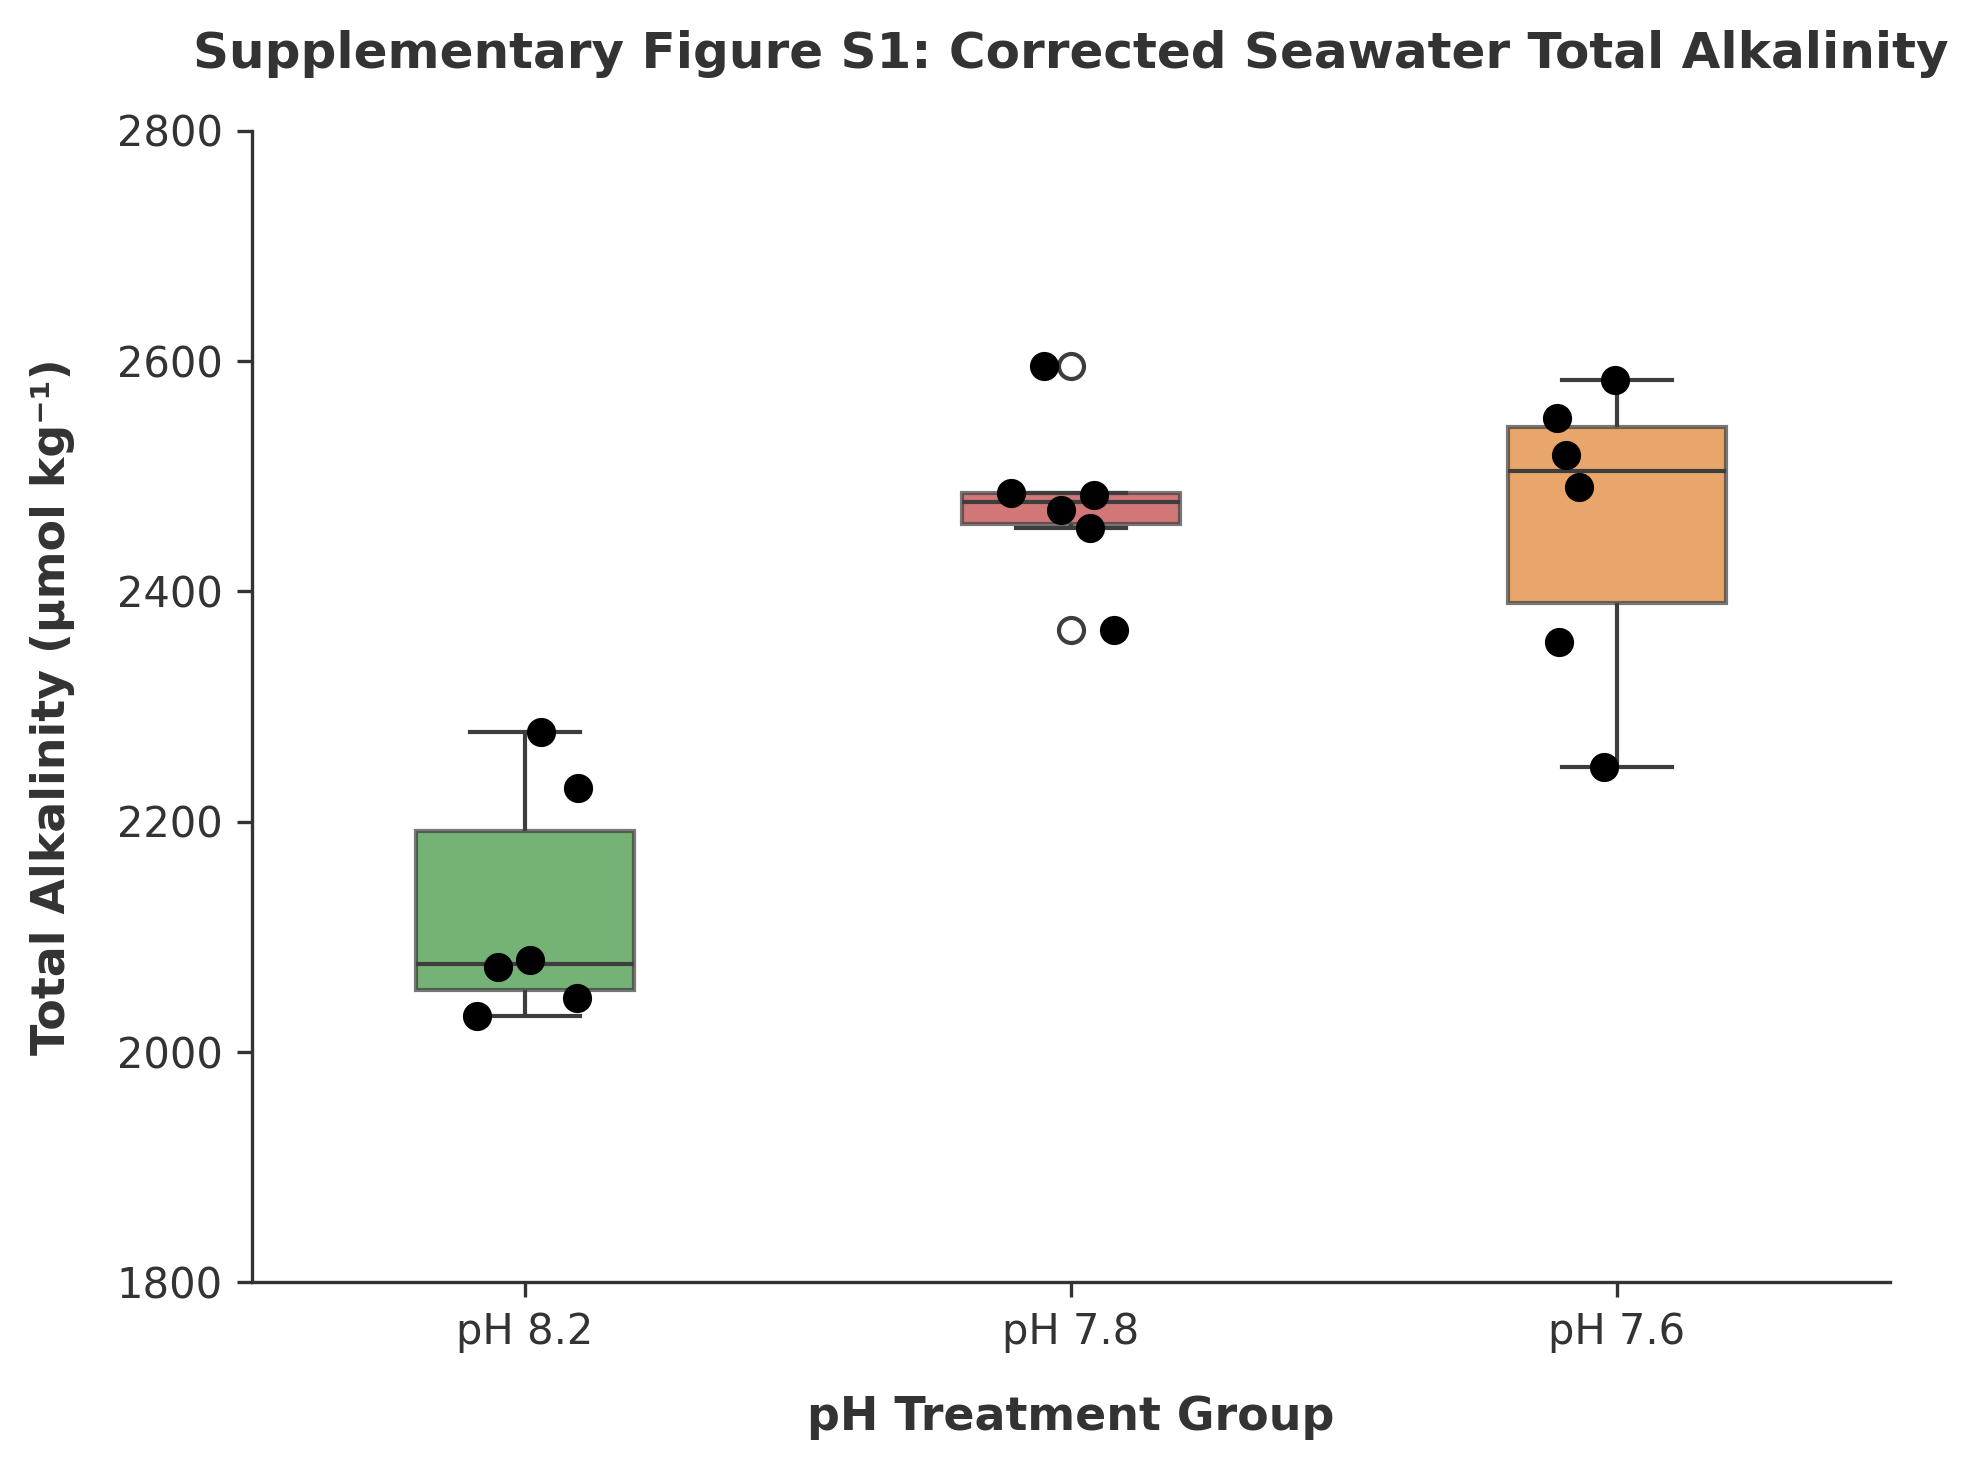

In [62]:
# ==============================================================================
# BLOCK 6: SUPPLEMENTARY FIGURE GENERATION
# ==============================================================================
fig, ax = plt.subplots(figsize=(6.5, 5), dpi=300)

palette = {'pH 8.2': '#2ca02c', 'pH 7.8': '#d62728', 'pH 7.6': '#ff7f0e'}
order = ['pH 8.2', 'pH 7.8', 'pH 7.6']  # Explicit order fix

# Boxplot + Overlaid Jittered Points
sns.boxplot(
    data=df_tank_summary, x='pH_Treatment', y='Mean_TA_Corrected', order=order,
    palette=palette, width=0.4, ax=ax, boxprops=dict(alpha=0.7), zorder=1
)
sns.stripplot(
    data=df_tank_summary, x='pH_Treatment', y='Mean_TA_Corrected', order=order,
    color='black', size=7, jitter=0.12, ax=ax, zorder=2
)

# Axis Styling & Labels
ax.set_xlabel('pH Treatment Group', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Total Alkalinity (µmol kg⁻¹)', fontsize=11, fontweight='bold', labelpad=10)
ax.set_title('Supplementary Figure S1: Corrected Seawater Total Alkalinity', fontsize=12, fontweight='bold', pad=15)
ax.set_ylim(1800, 2800)

# Clean Spines
sns.despine(top=True, right=True)
plt.tight_layout()

# Save Publication Images
plt.show()
